## Model 002 Review Checklist — `recommended` (logistic regression)

## Key Goal

Train and evaluate a logistic-classification baseline for `recommended` prediction.

## Decision It Supports

Whether classification features beat dumb baselines with usable precision/recall trade-offs.

## Primary Metrics

F1, AUPRC, ROC-AUC, accuracy (train/validation), plus baseline comparison deltas.


## Section Index

1. Setup and imports
2. Data loading
3. Metric helpers
4. Data sanity checks
5. Baselines + full **logistic regression** + `metrics_compare`
6. Diagnostics (scores, confusion)
7. Three-feature **logreg** + `metrics_compare_3feat`
8. Combined metrics table + charts
9. Export metrics CSV


## 1) Setup and Imports

In [1]:
import sys
from pathlib import Path


def _repo_root() -> Path:
    """Package outputs under repo `artifacts/` regardless of notebook kernel cwd."""
    here = Path.cwd().resolve()
    for d in [here, *here.parents]:
        if (d / "pyproject.toml").is_file():
            return d
    raise RuntimeError(
        "Could not find repo root (no pyproject.toml). "
        f"cwd={here}"
    )


REPO_ROOT = _repo_root()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from joblib import dump
from IPython.display import display

# Repo `src/` on path (use `pip install -e .` from repo root if you prefer)
_src = REPO_ROOT / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

from steam_review_ml.evaluation import classification_metrics

METRIC_FILENAME = "recommended_metrics.csv"


## 2) Data Loading

In [2]:
# load training data as pandas dataframe
df_train = pd.read_parquet(REPO_ROOT / "data/processed/steam_reviews_cleaned_english_train_norm.parquet")
df_val = pd.read_parquet(REPO_ROOT / "data/processed/steam_reviews_cleaned_english_val_norm.parquet")

## 3) Metric Helpers

In [3]:
# Metrics: `steam_review_ml.evaluation.classification_metrics` (same helper shape as `model_000` classification tables).


## 4) Data Sanity Checks

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df_train.head()

,review_id,app_id,app_name,author.steamid,language,review,recommended,votes_helpful,author.num_games_owned,author.num_reviews,author.playtime_last_two_weeks,author.playtime_at_review,steam_purchase,received_for_free,written_during_early_access,timestamp_created,author.last_played,is_helpful,review_word_count,review_length_chars,review_age_seconds,_norm_votes_helpful,_norm_author__playtime_last_two_weeks,_norm_author__playtime_at_review,_norm_author__num_games_owned,_norm_author__num_reviews,_norm_review_word_count
0,85184605,292030,The Witcher 3: Wild Hunt,76561199054755373,english,"One of the best RPG's of all time, worthy of a...",1,0,5,3,3200.0,5524.0,1,0,0,1611379970,1.611384e+09,0,12,59,45121.0,0.0,8.071219,8.617039,1.791759,1.386294,2.564949
1,85184171,292030,The Witcher 3: Wild Hunt,76561198170193529,english,"good story, good graphics. lots to do.",1,0,11,1,823.0,823.0,1,0,0,1611379264,1.611379e+09,0,7,38,45827.0,0.0,6.714171,6.714171,2.484907,0.693147,2.079442
2,85184064,292030,The Witcher 3: Wild Hunt,76561198119302812,english,"dis gud,",1,0,27,2,3398.0,4192.0,1,0,0,1611379091,1.611352e+09,0,2,8,46000.0,0.0,8.131237,8.341172,3.332205,1.098612,1.098612
3,85180436,292030,The Witcher 3: Wild Hunt,76561198065591528,english,favorite game of all time cant wait for the Ne...,1,0,33,1,177.0,23329.0,1,0,0,1611373086,1.611219e+09,0,11,59,52005.0,0.0,5.181784,10.057495,3.526361,0.693147,2.484907
4,85179753,292030,The Witcher 3: Wild Hunt,76561198996835044,english,Why wouldn't you get this,1,0,131,2,2004.0,8557.0,1,0,0,1611371978,1.611371e+09,0,5,25,53113.0,0.0,7.603399,9.054622,4.882802,1.098612,1.791759


In [6]:
df_train.columns

Index(['review_id', 'app_id', 'app_name', 'author.steamid', 'language',
       'review', 'recommended', 'votes_helpful', 'author.num_games_owned',
       'author.num_reviews', 'author.playtime_last_two_weeks',
       'author.playtime_at_review', 'steam_purchase', 'received_for_free',
       'written_during_early_access', 'timestamp_created',
       'author.last_played', 'is_helpful', 'review_word_count',
       'review_length_chars', 'review_age_seconds', '_norm_votes_helpful',
       '_norm_author__playtime_last_two_weeks',
       '_norm_author__playtime_at_review', '_norm_author__num_games_owned',
       '_norm_author__num_reviews', '_norm_review_word_count'],
      dtype='str')

In [7]:
# Class balance (recommended: 1 = thumbs up)
vc = pd.concat([df_train["recommended"], df_val["recommended"]]).astype(int).value_counts().sort_index()
print(vc)
print("train mean P(recommended=1):", df_train["recommended"].astype(float).mean())
print("val   mean P(recommended=1):", df_val["recommended"].astype(float).mean())


recommended
0     874468
1    6911024
Name: count, dtype: int64
train mean P(recommended=1): 0.887713381653175
val   mean P(recommended=1): 0.8875232135310245


## 5) Modeling and Evaluation

### Baseline predictors (`recommended`)

Dumb baselines aligned with **`model_000_baseline_dumb`**:

- **`predict_all_0`** — always class 0 (score 0.0).
- **`majority_train`** — always the train split mode (0/1); score equals that constant.
- **`prevalence_random`** — Bernoulli(`p_rec`) per row with `p_rec = train mean(recommended)`; uses `rng_rec = default_rng(RNG_SYNTHETIC_RECOMMENDED)` like model_000.

These are computed **before** fitting logistic regression so the main section can add the **`logreg_full_dataset`** row only.


In [8]:
from steam_review_ml.constants import PROJECT_RANDOM_SEED as SEED, RNG_SYNTHETIC_RECOMMENDED

# Match model_000_baseline_dumb: recommended prevalence RNG uses RNG_SYNTHETIC_RECOMMENDED.
rng_rec = np.random.default_rng(RNG_SYNTHETIC_RECOMMENDED)

y_train = df_train["recommended"].astype(int).to_numpy()
y_val = df_val["recommended"].astype(int).to_numpy()
p_rec = float(y_train.mean())
majority_rec = int(pd.Series(y_train).mode().iloc[0])

# --- predict_all_0 (scores for AUPRC/ROC) ---
b0_tr = np.zeros(len(df_train), dtype=int)
b0_va = np.zeros(len(df_val), dtype=int)
s0_tr = np.zeros(len(df_train), dtype=float)
s0_va = np.zeros(len(df_val), dtype=float)

# --- majority_train ---
bm_tr = np.full(len(df_train), majority_rec, dtype=int)
bm_va = np.full(len(df_val), majority_rec, dtype=int)
sm_tr = np.full(len(df_train), float(majority_rec), dtype=float)
sm_va = np.full(len(df_val), float(majority_rec), dtype=float)

# --- prevalence_random (score proxy = predicted label, same as hard baselines in model_000) ---
br_tr = rng_rec.binomial(1, p_rec, size=len(df_train)).astype(int)
br_va = rng_rec.binomial(1, p_rec, size=len(df_val)).astype(int)
sr_tr = br_tr.astype(float)
sr_va = br_va.astype(float)


## 6) Full Dataset Model


In [9]:
LOGREG_MODEL_NAME = "recommended_logreg_full_dataset.pkl"


In [10]:
# Logistic regression on tabular features only (no review text, no ids, no target / raw helpful count).
logreg = LogisticRegression(max_iter=5000, random_state=SEED, solver="lbfgs")

training_cols = [
    "_norm_author__num_games_owned",
    "_norm_author__num_reviews",
    "_norm_author__playtime_last_two_weeks",
    "_norm_author__playtime_at_review",
    "steam_purchase",
    "received_for_free",
    "written_during_early_access",
    "timestamp_created",
    "author.last_played",
    "review_length_chars",
    "_norm_review_word_count",
]

logreg.fit(
    df_train[training_cols],
    df_train["recommended"].astype(int),
)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",2026
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Train

In [11]:
# Predicted probabilities + 0.5 threshold labels; metrics vs baselines
proba_tr = logreg.predict_proba(df_train[training_cols])[:, 1]
proba_va = logreg.predict_proba(df_val[training_cols])[:, 1]
pred_tr = (proba_tr >= 0.5).astype(int)
pred_va = (proba_va >= 0.5).astype(int)

df_train["recommended_proba_logreg"] = proba_tr
df_val["recommended_proba_logreg"] = proba_va
df_train["recommended_pred_logreg"] = pred_tr
df_val["recommended_pred_logreg"] = pred_va

pred_rows = [
    ("predict_all_0", b0_tr, b0_va, s0_tr, s0_va),
    ("majority_train", bm_tr, bm_va, sm_tr, sm_va),
    ("prevalence_random", br_tr, br_va, sr_tr, sr_va),
    ("logreg_full_dataset", pred_tr, pred_va, proba_tr, proba_va),
]

y_tr = df_train["recommended"].astype(int).to_numpy()
y_va = df_val["recommended"].astype(int).to_numpy()

table_rows = []
for name, pt_tr, pt_va, sc_tr, sc_va in pred_rows:
    tr = classification_metrics(y_tr, pt_tr, y_score=sc_tr)
    va = classification_metrics(y_va, pt_va, y_score=sc_va)
    row = {"model": name}
    for k, v in tr.items():
        row[f"train_{k}"] = v
    for k, v in va.items():
        row[f"val_{k}"] = v
    table_rows.append(row)

metrics_compare = pd.DataFrame(table_rows)
numeric_cols = [c for c in metrics_compare.columns if c != "model"]
for c in numeric_cols:
    if c.startswith("val_"):
        k = c.replace("val_", "", 1)
        tc = f"train_{k}"
        if tc in metrics_compare.columns:
            metrics_compare[f"gap_{k}"] = metrics_compare[c] - metrics_compare[tc]

metrics_compare


,model,train_accuracy,train_f1,train_f2,train_precision,train_recall,train_specificity,train_mcc,train_auprc,train_roc_auc,val_accuracy,val_f1,val_f2,val_precision,val_recall,val_specificity,val_mcc,val_auprc,val_roc_auc,gap_accuracy,gap_f1,gap_f2,gap_precision,gap_recall,gap_specificity,gap_mcc,gap_auprc,gap_roc_auc
0,predict_all_0,0.112287,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.887713,0.500000,0.112477,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.887523,0.500000,0.000190,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,-0.000190,0.000000
1,majority_train,0.887713,0.940517,0.975326,0.887713,1.000000,0.000000,0.000000,0.887713,0.500000,0.887523,0.940410,0.975280,0.887523,1.000000,0.000000,0.000000,0.887523,0.500000,-0.000190,-0.000107,-0.000046,-0.000190,0.00000,0.000000,0.000000,-0.000190,0.000000
2,prevalence_random,0.800514,0.887635,0.887607,0.887680,0.887589,0.112116,-0.000295,0.887684,0.499853,0.800606,0.887706,0.887881,0.887412,0.887999,0.111016,-0.000987,0.887425,0.499507,0.000092,0.000071,0.000274,-0.000268,0.00041,-0.001100,-0.000693,-0.000259,-0.000345
3,logreg_full_dataset,0.887519,0.940407,0.975145,0.887703,0.999765,0.000129,-0.002236,0.910400,0.600455,0.887343,0.940308,0.975108,0.887518,0.999775,0.000175,-0.001082,0.910266,0.600664,-0.000177,-0.000099,-0.000037,-0.000185,0.00001,0.000045,0.001153,-0.000134,0.000209


In [12]:
# Save fitted model bundle (metrics CSV written in export cell)
artifacts_root = REPO_ROOT / "artifacts"
model_dir = artifacts_root / "models" / "tabular"
model_dir.mkdir(parents=True, exist_ok=True)

model_bundle = {
    "estimator": logreg,
    "feature_columns": training_cols,
    "target": "recommended",
    "positive_class": 1,
    "decision_threshold": 0.5,
}
model_path = model_dir / LOGREG_MODEL_NAME
dump(model_bundle, model_path)
print(f"Saved model bundle -> {model_path}")


Saved model bundle -> /home/ryanr/workspace/steam_recommendations/artifacts/models/tabular/recommended_logreg_full_dataset.pkl


### Diagnostics (scores & confusion)


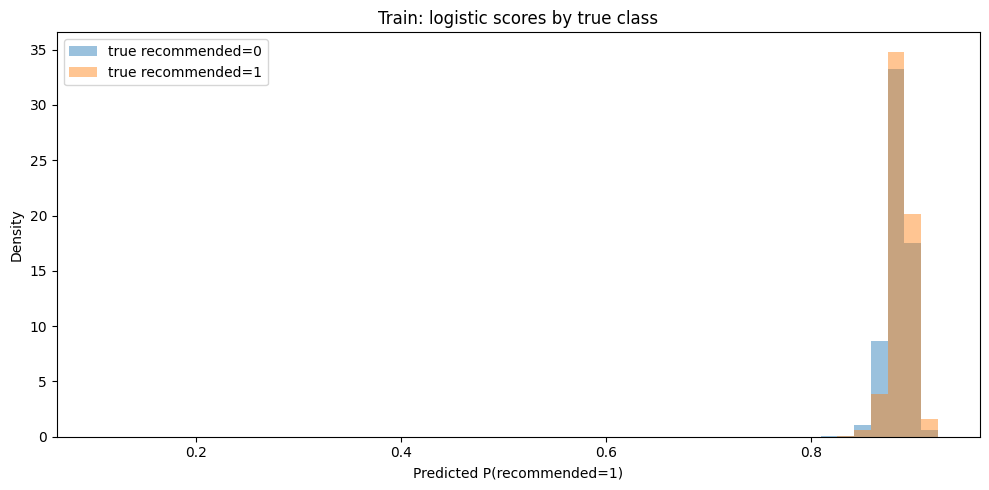

In [13]:
# P(recommended=1) by true label — train
plt.figure(figsize=(10, 5))
for y in (0, 1):
    m = df_train["recommended"].astype(int).to_numpy() == y
    plt.hist(proba_tr[m], bins=50, alpha=0.45, label=f"true recommended={y}", density=True)
plt.xlabel("Predicted P(recommended=1)")
plt.ylabel("Density")
plt.title("Train: logistic scores by true class")
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
# Row with highest P(recommended=1) on train
idx = int(np.argmax(proba_tr))
print("Highest recommended_proba_logreg on train, index:", idx)
display(df_train.loc[[idx]].T)


Highest recommended_proba_logreg on train, index: 448737


,448737
review_id,2615509
app_id,4000
app_name,Garry's Mod
author.steamid,76561198010077714
language,english
review,Amusing unique game. Many different gamemodes ...
recommended,1
votes_helpful,0
author.num_games_owned,187
author.num_reviews,14


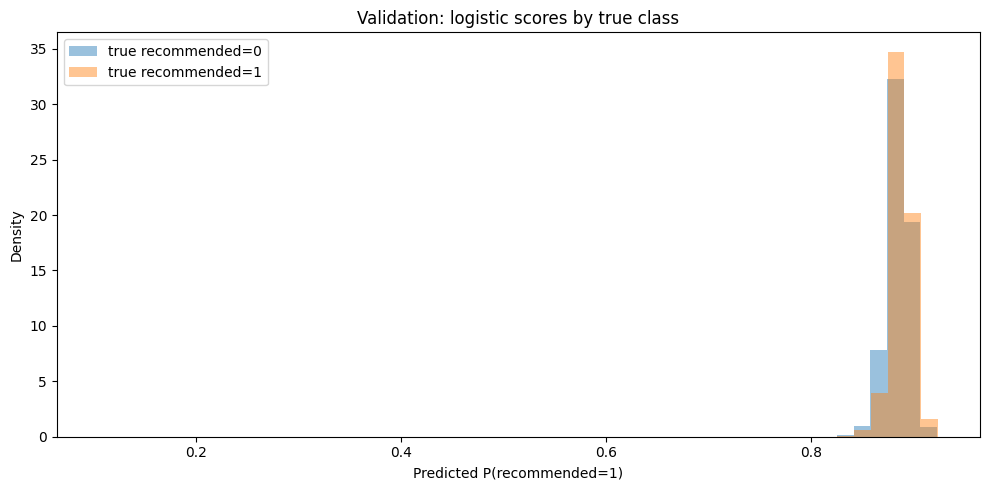

In [15]:
# Same on validation
plt.figure(figsize=(10, 5))
for y in (0, 1):
    m = df_val["recommended"].astype(int).to_numpy() == y
    plt.hist(proba_va[m], bins=50, alpha=0.45, label=f"true recommended={y}", density=True)
plt.xlabel("Predicted P(recommended=1)")
plt.ylabel("Density")
plt.title("Validation: logistic scores by true class")
plt.legend()
plt.tight_layout()
plt.show()


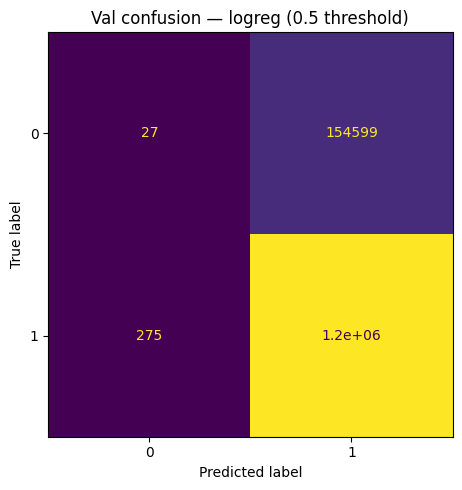

In [16]:
# Confusion matrix — validation, threshold 0.5
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    df_val["recommended"].astype(int),
    df_val["recommended_pred_logreg"].astype(int),
    labels=[0, 1],
    ax=ax,
    colorbar=False,
)
ax.set_title("Val confusion — logreg (0.5 threshold)")
plt.tight_layout()
plt.show()


In [17]:
# Coefficients (log-odds scale)
coef = pd.Series(logreg.coef_.ravel(), index=training_cols).sort_values(key=np.abs, ascending=False)
coef


author.last_played                       2.614821e-09
timestamp_created                       -1.327820e-09
review_length_chars                     -1.313472e-13
_norm_review_word_count                 -4.665944e-16
_norm_author__playtime_last_two_weeks    2.807490e-16
_norm_author__playtime_at_review         2.389937e-16
_norm_author__num_games_owned           -2.105443e-16
_norm_author__num_reviews               -1.279502e-16
written_during_early_access             -1.608418e-17
steam_purchase                           9.188682e-18
received_for_free                       -6.819510e-19
dtype: float64

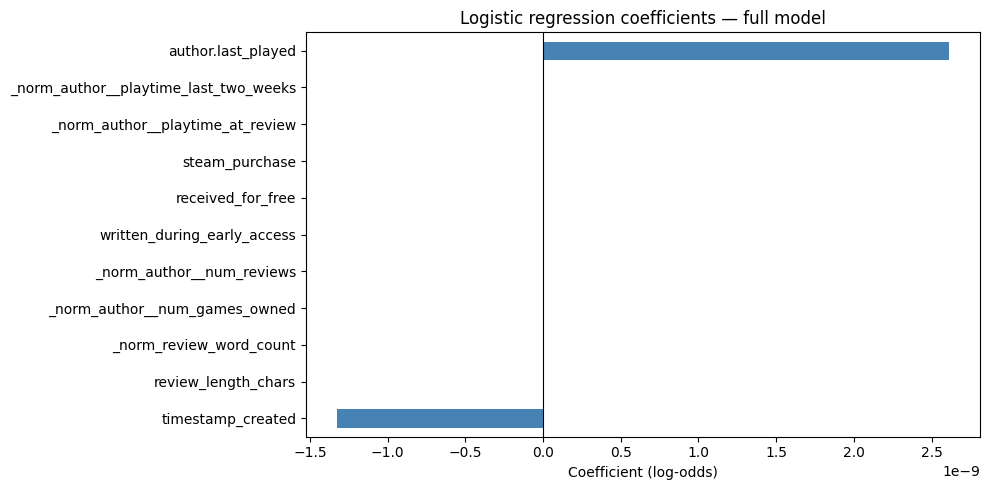

In [18]:
# Bar chart — coefficient magnitudes
plt.figure(figsize=(10, 5))
coef.sort_values().plot(kind="barh", color="steelblue")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient (log-odds)")
plt.title("Logistic regression coefficients — full model")
plt.tight_layout()
plt.show()


In [19]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[
        go.Bar(
            x=training_cols,
            y=logreg.coef_.ravel(),
            marker_color="steelblue",
            text=[f"{c:.4g}" for c in logreg.coef_.ravel()],
            textposition="outside",
        )
    ]
)
fig.update_layout(
    title="Coefficients — full logistic model (recommended)",
    xaxis_title="Feature",
    yaxis_title="Coefficient",
    xaxis_tickangle=45,
    height=480,
    width=900,
    margin=dict(b=120),
)
fig.show()


## 7) Three-feature restricted model


### Three features

Same restricted set as **`model_001`**: normalized review count, raw character length, normalized word count.


In [20]:
LOGREG_3FEAT_MODEL_NAME = "recommended_logreg_3feat.pkl"


In [21]:
logreg_3 = LogisticRegression(max_iter=5000, random_state=SEED, solver="lbfgs")

training_cols_3 = [
    "_norm_author__num_reviews",
    "review_length_chars",
    "_norm_review_word_count",
]

logreg_3.fit(
    df_train[training_cols_3],
    df_train["recommended"].astype(int),
)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",2026
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Train


In [22]:
# Distinct columns so full-model diagnostics stay unchanged
proba3_tr = logreg_3.predict_proba(df_train[training_cols_3])[:, 1]
proba3_va = logreg_3.predict_proba(df_val[training_cols_3])[:, 1]
pred3_tr = (proba3_tr >= 0.5).astype(int)
pred3_va = (proba3_va >= 0.5).astype(int)

df_train["recommended_proba_logreg_3feat"] = proba3_tr
df_val["recommended_proba_logreg_3feat"] = proba3_va
df_train["recommended_pred_logreg_3feat"] = pred3_tr
df_val["recommended_pred_logreg_3feat"] = pred3_va

y_tr = df_train["recommended"].astype(int).to_numpy()
y_va = df_val["recommended"].astype(int).to_numpy()

tr_m = classification_metrics(y_tr, pred3_tr, y_score=proba3_tr)
va_m = classification_metrics(y_va, pred3_va, y_score=proba3_va)

row = {"model": "logreg_3feat_norm_reviews__len_chars__norm_word_count"}
for k, v in tr_m.items():
    row[f"train_{k}"] = v
for k, v in va_m.items():
    row[f"val_{k}"] = v

metrics_compare_3feat = pd.DataFrame([row])
numeric_cols = [c for c in metrics_compare_3feat.columns if c != "model"]
for c in numeric_cols:
    if c.startswith("val_"):
        k = c.replace("val_", "", 1)
        tc = f"train_{k}"
        if tc in metrics_compare_3feat.columns:
            metrics_compare_3feat[f"gap_{k}"] = metrics_compare_3feat[c] - metrics_compare_3feat[tc]

metrics_compare_3feat


,model,train_accuracy,train_f1,train_f2,train_precision,train_recall,train_specificity,train_mcc,train_auprc,train_roc_auc,val_accuracy,val_f1,val_f2,val_precision,val_recall,val_specificity,val_mcc,val_auprc,val_roc_auc,gap_accuracy,gap_f1,gap_f2,gap_precision,gap_recall,gap_specificity,gap_mcc,gap_auprc,gap_roc_auc
0,logreg_3feat_norm_reviews__len_chars__norm_wor...,0.887713,0.940517,0.975326,0.887713,1.0,0.0,0.0,0.932932,0.664144,0.887523,0.94041,0.97528,0.887523,1.0,0.0,0.0,0.932843,0.663553,-0.00019,-0.000107,-0.000046,-0.00019,0.0,0.0,0.0,-0.000089,-0.000591


In [23]:
artifacts_root = REPO_ROOT / "artifacts"
model_dir = artifacts_root / "models" / "tabular"
model_dir.mkdir(parents=True, exist_ok=True)

model_bundle_3 = {
    "estimator": logreg_3,
    "feature_columns": training_cols_3,
    "target": "recommended",
    "positive_class": 1,
    "decision_threshold": 0.5,
}
model_path_3 = model_dir / LOGREG_3FEAT_MODEL_NAME
dump(model_bundle_3, model_path_3)
print(f"Saved 3-feature model bundle -> {model_path_3}")


Saved 3-feature model bundle -> /home/ryanr/workspace/steam_recommendations/artifacts/models/tabular/recommended_logreg_3feat.pkl


### Diagnostics (3-feature model)

Same style as full model; columns `*_3feat`.


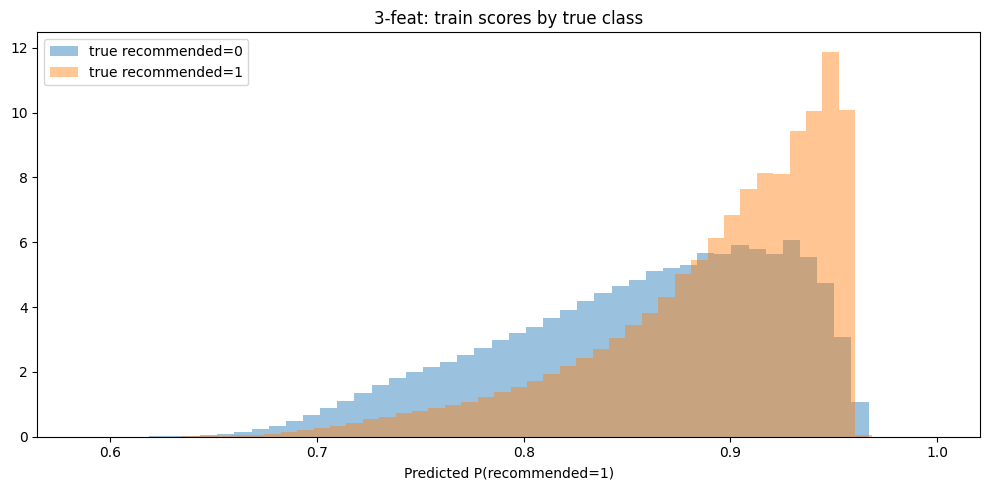

In [24]:
plt.figure(figsize=(10, 5))
for y in (0, 1):
    m = df_train["recommended"].astype(int).to_numpy() == y
    plt.hist(proba3_tr[m], bins=50, alpha=0.45, label=f"true recommended={y}", density=True)
plt.xlabel("Predicted P(recommended=1)")
plt.title("3-feat: train scores by true class")
plt.legend()
plt.tight_layout()
plt.show()


In [25]:
idx3 = int(np.argmax(proba3_tr))
print("Highest recommended_proba_logreg_3feat on train, index:", idx3)
display(df_train.loc[[idx3]].T)


Highest recommended_proba_logreg_3feat on train, index: 3858951


,3858951
review_id,33702432
app_id,379720
app_name,DOOM
author.steamid,76561198320925817
language,english
review,[list][list][list][/list][/list][/list] \n[quo...
recommended,0
votes_helpful,0
author.num_games_owned,103
author.num_reviews,10


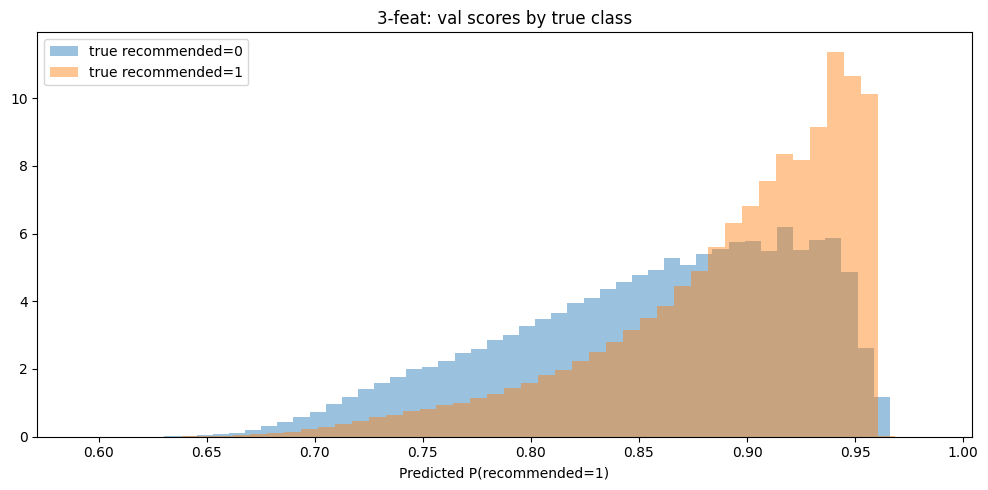

In [26]:
plt.figure(figsize=(10, 5))
for y in (0, 1):
    m = df_val["recommended"].astype(int).to_numpy() == y
    plt.hist(proba3_va[m], bins=50, alpha=0.45, label=f"true recommended={y}", density=True)
plt.xlabel("Predicted P(recommended=1)")
plt.title("3-feat: val scores by true class")
plt.legend()
plt.tight_layout()
plt.show()


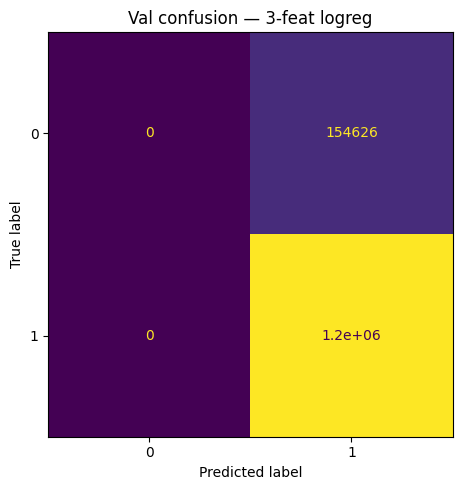

In [27]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    df_val["recommended"].astype(int),
    df_val["recommended_pred_logreg_3feat"].astype(int),
    labels=[0, 1],
    ax=ax,
    colorbar=False,
)
ax.set_title("Val confusion — 3-feat logreg")
plt.tight_layout()
plt.show()


In [28]:
pd.Series(logreg_3.coef_.ravel(), index=training_cols_3).sort_values(key=np.abs, ascending=False)


_norm_review_word_count     -0.439868
_norm_author__num_reviews   -0.101503
review_length_chars          0.000118
dtype: float64

In [29]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[
        go.Bar(
            x=training_cols_3,
            y=logreg_3.coef_.ravel(),
            marker_color="teal",
            text=[f"{c:.4g}" for c in logreg_3.coef_.ravel()],
            textposition="outside",
        )
    ]
)
fig.update_layout(
    title="Coefficients — 3-feature logistic model",
    xaxis_title="Feature",
    yaxis_title="Coefficient",
    height=480,
    width=720,
    margin=dict(b=80),
)
fig.show()


In [30]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[
        go.Bar(
            x=training_cols_3,
            y=logreg_3.coef_.ravel(),
            marker_color="teal",
            text=[f"{c:.4g}" for c in logreg_3.coef_.ravel()],
            textposition="outside",
        )
    ]
)
fig.update_layout(
    title="Coefficients — 3-feature logistic model (norm review count / raw length / norm word count)",
    xaxis_title="Feature",
    yaxis_title="Coefficient",
    xaxis_tickangle=45,
    height=480,
    width=720,
    margin=dict(b=120),
)
fig.show()



# Metric evaluation


In [31]:
# All models: baselines + full logreg + optional 3-feat row
_metric_parts = [metrics_compare]
if "metrics_compare_3feat" in globals():
    _metric_parts.append(metrics_compare_3feat)
metrics_compare_all = pd.concat(_metric_parts, ignore_index=True)
metrics_compare_all


,model,train_accuracy,train_f1,train_f2,train_precision,train_recall,train_specificity,train_mcc,train_auprc,train_roc_auc,val_accuracy,val_f1,val_f2,val_precision,val_recall,val_specificity,val_mcc,val_auprc,val_roc_auc,gap_accuracy,gap_f1,gap_f2,gap_precision,gap_recall,gap_specificity,gap_mcc,gap_auprc,gap_roc_auc
0,predict_all_0,0.112287,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.887713,0.500000,0.112477,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.887523,0.500000,0.000190,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,-0.000190,0.000000
1,majority_train,0.887713,0.940517,0.975326,0.887713,1.000000,0.000000,0.000000,0.887713,0.500000,0.887523,0.940410,0.975280,0.887523,1.000000,0.000000,0.000000,0.887523,0.500000,-0.000190,-0.000107,-0.000046,-0.000190,0.00000,0.000000,0.000000,-0.000190,0.000000
2,prevalence_random,0.800514,0.887635,0.887607,0.887680,0.887589,0.112116,-0.000295,0.887684,0.499853,0.800606,0.887706,0.887881,0.887412,0.887999,0.111016,-0.000987,0.887425,0.499507,0.000092,0.000071,0.000274,-0.000268,0.00041,-0.001100,-0.000693,-0.000259,-0.000345
3,logreg_full_dataset,0.887519,0.940407,0.975145,0.887703,0.999765,0.000129,-0.002236,0.910400,0.600455,0.887343,0.940308,0.975108,0.887518,0.999775,0.000175,-0.001082,0.910266,0.600664,-0.000177,-0.000099,-0.000037,-0.000185,0.00001,0.000045,0.001153,-0.000134,0.000209
4,logreg_3feat_norm_reviews__len_chars__norm_wor...,0.887713,0.940517,0.975326,0.887713,1.000000,0.000000,0.000000,0.932932,0.664144,0.887523,0.940410,0.975280,0.887523,1.000000,0.000000,0.000000,0.932843,0.663553,-0.000190,-0.000107,-0.000046,-0.000190,0.00000,0.000000,0.000000,-0.000089,-0.000591


In [32]:
import plotly.graph_objects as go
import plotly.subplots as sp

metrics_to_plot = ["accuracy", "f1", "auprc", "roc_auc"]
n_metrics = len(metrics_to_plot)

fig = sp.make_subplots(
    rows=1,
    cols=n_metrics,
    subplot_titles=[m.upper() for m in metrics_to_plot],
)

for i, metric in enumerate(metrics_to_plot):
    train_metric = f"train_{metric}"
    val_metric = f"val_{metric}"

    fig.add_trace(
        go.Bar(
            x=metrics_compare_all["model"],
            y=metrics_compare_all[train_metric],
            name="Train",
            marker_color="steelblue",
            text=metrics_compare_all[train_metric].round(3),
            textposition="auto",
        ),
        row=1,
        col=i + 1,
    )
    fig.add_trace(
        go.Bar(
            x=metrics_compare_all["model"],
            y=metrics_compare_all[val_metric],
            name="Val",
            marker_color="darkorange",
            text=metrics_compare_all[val_metric].round(3),
            textposition="auto",
        ),
        row=1,
        col=i + 1,
    )
    fig.update_traces(showlegend=(i == 0), row=1, col=i + 1)
    fig.update_xaxes(title_text="Model", tickangle=45, row=1, col=i + 1)
    fig.update_yaxes(title_text=metric.upper(), row=1, col=i + 1)

fig.update_layout(
    barmode="group",
    width=4 * n_metrics * 100,
    height=700,
    title_text="Classification metrics — all models (baselines + logreg + 3-feat)",
    legend_title_text="Split",
    margin=dict(t=60, l=20, r=20, b=50),
)
fig.show()


In [33]:
# gap_* = val − train (same metric name)

import plotly.graph_objs as go
from plotly.subplots import make_subplots

gap_metrics = ["gap_accuracy", "gap_f1", "gap_auprc", "gap_roc_auc"]

fig = make_subplots(
    rows=1,
    cols=len(gap_metrics),
    subplot_titles=[m.upper() for m in gap_metrics],
)

for i, metric in enumerate(gap_metrics):
    fig.add_trace(
        go.Bar(
            x=metrics_compare_all["model"],
            y=metrics_compare_all[metric],
            marker_color="mediumslateblue",
            text=metrics_compare_all[metric].round(4),
            textposition="outside",
            name=metric.upper(),
        ),
        row=1,
        col=i + 1,
    )
    fig.update_xaxes(title_text="Model", tickangle=45, row=1, col=i + 1)
    fig.update_yaxes(title_text=metric.upper(), row=1, col=i + 1)

fig.update_layout(
    showlegend=False,
    width=4 * len(gap_metrics) * 120,
    height=740,
    title_text="Gap metrics (val − train) — all models",
    margin=dict(t=160, l=20, r=20, b=60),
)

fig.show()

print(
    "Interpretation (gap = val - train):"
    "Accuracy / F1 / AUPRC / ROC-AUC: sign tells you direction; large gaps may indicate overfitting or split shift."
)


Interpretation (gap = val - train):Accuracy / F1 / AUPRC / ROC-AUC: sign tells you direction; large gaps may indicate overfitting or split shift.


# Export metrics

Run after **Metric evaluation** so `metrics_compare_all` exists. CSV name from `METRIC_FILENAME` in the **Setup and imports** cell.


In [34]:
artifacts_root = REPO_ROOT / "artifacts"
metrics_dir = artifacts_root / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

if "metrics_compare_all" in globals():
    metrics_export = metrics_compare_all
else:
    _parts = [metrics_compare]
    if "metrics_compare_3feat" in globals():
        _parts.append(metrics_compare_3feat)
    metrics_export = pd.concat(_parts, ignore_index=True)

out_path = metrics_dir / METRIC_FILENAME
metrics_export.to_csv(out_path, index=False)
print(f"Wrote metrics ({len(metrics_export)} rows) -> {out_path}")


Wrote metrics (5 rows) -> /home/ryanr/workspace/steam_recommendations/artifacts/metrics/recommended_metrics.csv
